# Two-Dimensional Simulation

We compare several oracle and empirical Bayes denoising methods on a simulated bivariate data set. The notebook reports Monte Carlo approximations of the denoising and deconvolution errors (assembled into a LaTeX table) and visualizes the oracle and empirical denoisers on a single sampled data set. These reproduce the corresponding two-dimensional simulation table and figure in the paper (see the figure-mapping table in the README).

In [1]:
from npeb.GLMixture import *
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import itertools
import scipy.stats as stats
from scipy.linalg import sqrtm, inv
from scipy.spatial import distance_matrix
import ot

/Users/aqjaffe/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/aqjaffe/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Set up simulation

We sample the latent variables $\Theta_1,\ldots,\Theta_n$ from a two-component Gaussian mixture $G$ on $\mathbb{R}^2$, with component centers $c_1 = (0.5, 0.5)^{\top}$ and $c_2 = (-0.5, -0.5)^{\top}$ and component variance $\tau^2 I_2$ for $\tau^2 = 0.1$. Conditionally on the latent variables, the observations are drawn from a Gaussian likelihood with variance $\sigma^2 I_2$ for $\sigma^2 = 1.0$.

In [2]:
n = 2500
B = 10
center1 = np.asarray([0.5, 0.5])
center2 = np.asarray([-0.5, -0.5])
tau2 = 0.1
sigma2 = 1.0
K = 150

np.random.seed(54321)

In [3]:
centers = np.vstack([center1,center2])

def sample_latent(nsamples,var):
    classes = np.random.randint(0,2,size=nsamples)
    indices = np.zeros((nsamples,2))
    indices[np.arange(nsamples),classes] = 1
    Theta = np.random.normal(indices@centers,np.sqrt(var))
    return Theta

In [4]:
denoisers = ['MLE', 'OB', 'EB', 'OVCB', 'EVCB', 'ODCB', 'EDCB']
risks = np.zeros((len(denoisers),B))
dists = np.zeros((len(denoisers)+1,B))

n_oracle = 10000
ob_model = GLMixture(prec_type='diagonal')
Theta_oracle = sample_latent(n_oracle,tau2)
ob_model.set_params(atoms=Theta_oracle, weights=np.ones(n_oracle)/n_oracle)

In [5]:
def reduce(at, wt, eps):
    at_ = at[wt > eps]
    wt_ = wt[wt > eps]
    return at_, wt_/np.sum(wt_)

In [6]:
Eta_x = np.linspace(-1.5,1.5,K)
Eta_y = np.linspace(-1.5,1.5,K)
Eta = np.array(list(itertools.product(Eta_x,Eta_y)))
rv1 = stats.multivariate_normal(mean=center1, cov=[tau2, tau2])
rv2 = stats.multivariate_normal(mean=center2, cov=[tau2, tau2])
G_wt = rv1.pdf(Eta) + rv2.pdf(Eta)
G_wt = G_wt/np.sum(G_wt)
Eta_, G_wt_ = reduce(Eta, G_wt, 1e-5)

In [7]:
def denoising_err(delta_vals, theta):
    return np.mean(np.sum(np.square(delta_vals-theta),axis=1))

def deconvolution_err(delta_vals, at, wt):
    return ot.emd2([], wt, ot.dist(delta_vals, at), numItermax=1e6)

## Run simulation

We execute the simulation above, recording the denoising and deconvolution errors of each method across the `B` Monte Carlo replications.

In [8]:
# NOTE: Longest-running cell in this notebook. This Monte Carlo simulation loop
# dominates the ~55 min runtime (see the README).
for b in range(B):
    print(b, end=' ')
    Theta =  sample_latent(n,tau2)
    prec = np.ones_like(Theta)/sigma2
    prec_smooth = 1./(1./prec + tau2)
    Z = np.random.normal(Theta,np.sqrt(sigma2),size=(n,2))
    L = np.max(Z)
    
    # MLE
    risks[0, b] = denoising_err(Z, Theta)
    dists[0, b] = deconvolution_err(Z, Eta_, G_wt_)

    # oracle Bayes
    ob = ob_model.posterior_mean(Z, prec)
    risks[1, b] = denoising_err(ob, Theta)
    dists[1, b] = deconvolution_err(ob, Eta_, G_wt_)
    
    # empirical Bayes
    eb_model = GLMixture(prec_type='diagonal')
    eb_model.fit(Z, 1./(tau2 + 1./prec))
    eb_post_means = eb_model.posterior_mean(Z, 1./(1./prec + tau2))
    eb = tau2 * Z / (tau2 + 1./prec) + (1./prec) * eb_post_means / (tau2 + 1./prec)
    risks[2, b] = denoising_err(eb, Theta)
    dists[2, b] = deconvolution_err(eb, Eta_, G_wt_)
    
    # oracle VCB
    M = np.cov(ob.T)
    A = np.cov(Theta.T)
    transport = inv(sqrtm(M))@sqrtm(sqrtm(M)@A@sqrtm(M))@inv(sqrtm(M))
    ovcb = ob@transport
    risks[3, b] = denoising_err(ovcb, Theta)
    dists[3, b] = deconvolution_err(ovcb, Eta_, G_wt_)
    
    # empirical VCB
    c = np.mean(eb,axis=0)
    M_hat = (eb-c).T@(eb-c)/n
    mu_hat = np.mean(Z,axis=0)
    A_hat = (Z-mu_hat).T@(Z-mu_hat)/n - sigma2*np.eye(2)
    transport_hat = inv(sqrtm(M_hat))@sqrtm(sqrtm(M_hat)@A_hat@sqrtm(M_hat))@inv(sqrtm(M_hat))
    evcb = (eb - mu_hat)@transport_hat + mu_hat
    risks[4, b] = denoising_err(evcb, Theta)
    dists[4, b] = deconvolution_err(evcb, Eta_, G_wt_)
    
    # oracle DCB
    pi = ot.emd(np.ones(n)/n, G_wt_, ot.dist(ob, Eta_), numItermax=1e6)
    odcb = np.zeros((n,2))
    for i in range(n):
        odcb[i,:] = (pi[i,:].reshape(1,-1)@Eta_)/np.sum(pi[i,:])
    risks[5, b] = denoising_err(odcb, Theta)
    dists[5, b] = deconvolution_err(odcb, Eta_, G_wt_)
    
    # empirical DCB
    edcb = np.zeros((n,2))
    at, wt = eb_model.get_params()
    m = len(wt)
    Ghat_wt = np.zeros(K**2)
    for i in range(m):
        rv = stats.multivariate_normal(mean=at[i,:], cov=[tau2, tau2])
        probs = rv.pdf(Eta)
        Ghat_wt += probs * wt[i] / np.sum(probs)
    Ghat_wt = Ghat_wt/np.sum(Ghat_wt)
    Eta_hat_, Ghat_wt_ = reduce(Eta, Ghat_wt, 1e-5)
    pi = ot.emd(np.ones(n)/n, Ghat_wt_, ot.dist(eb, Eta_hat_), numItermax=1e6)
    edcb = np.zeros((n,2))
    for i in range(n):
        edcb[i,:] = (pi[i,:].reshape(1,-1)@Eta_hat_)/np.sum(pi[i,:])
    risks[6, b] = denoising_err(edcb, Theta)
    dists[6, b] = deconvolution_err(edcb, Eta_, G_wt_)
        
    # deconvolution
    dists[7, b] = ot.emd2(Ghat_wt_, G_wt_, ot.dist(Eta_hat_, Eta_), numItermax=1e6)

0 1 2 3 4 5 6 7 8 9 

MLE:	2.000	+/-0.033
OB:	0.462	+/-0.009
EB:	0.469	+/-0.007
OVCB:	0.598	+/-0.014
EVCB:	0.604	+/-0.023
ODCB:	0.590	+/-0.013
EDCB:	0.601	+/-0.021


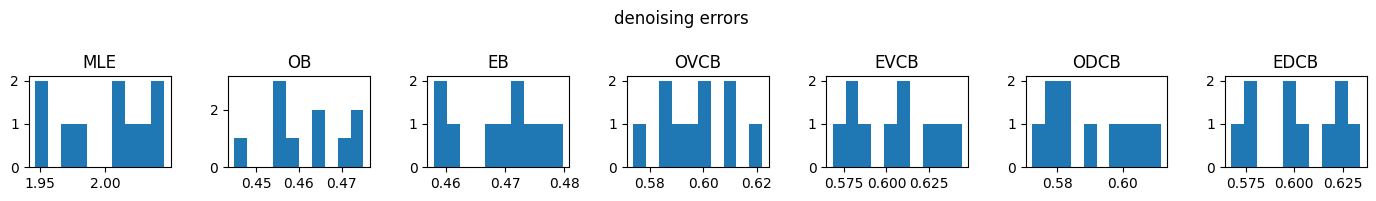

In [9]:
fig, ax = plt.subplots(1, 7, figsize=(14,2))

for d in range(len(denoisers)):
    ax[d].hist(risks[d,:])
    ax[d].set_title(denoisers[d])
    print('%s' % denoisers[d] + ':\t%1.3f' % np.mean(risks[d,:]) + '\t+/-%1.3f' % np.std(risks[d,:]))

plt.suptitle('denoising errors')
plt.tight_layout()

MLE:	0.879	+/-0.033
OB:	0.130	+/-0.004
EB:	0.126	+/-0.023
OVCB:	0.014	+/-0.001
EVCB:	0.044	+/-0.012
ODCB:	0.000	+/-0.000
EDCB:	0.014	+/-0.006


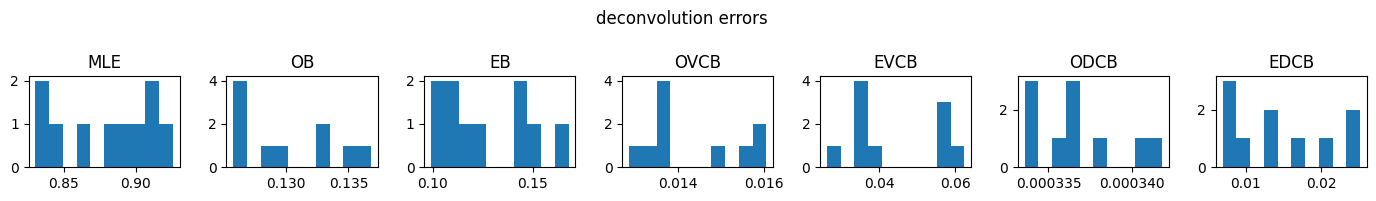

In [10]:
fig, ax = plt.subplots(1, 7, figsize=(14,2))

for d in range(len(denoisers)):
    ax[d].hist(dists[d,:])
    ax[d].set_title(denoisers[d])
    print('%s' % denoisers[d] + ':\t%1.3f' % np.mean(dists[d,:]) + '\t+/-%1.3f' % np.std(dists[d,:]))

plt.suptitle('deconvolution errors')
plt.tight_layout()

In [25]:
full   = '$%s$ & $%1.4f\\pm%1.4f$ & $%1.4f\\pm%1.4f$'   # label, denoising, deconv
dashes = '--- & --- & ---'

def cell(label, idx):
    return full % (label, np.mean(risks[idx, :]), np.std(risks[idx, :]),
                          np.mean(dists[idx, :]), np.std(dists[idx, :]))

# (oracle label, oracle idx, empirical label, empirical idx-or-None)
rows = [
    ('\\delta_{\\textnormal{MLE}}',  0, None,                            None),
    ('\\delta_{\\mathcal{B}}',       1, '\\hat{\\delta}_{\\mathcal{B}}',   2),
    ('\\delta_{\\mathcal{VCB}}',     3, '\\hat{\\delta}_{\\mathcal{VCB}}', 4),
    ('\\delta_{\\mathcal{DCB}}',     5, '\\hat{\\delta}_{\\mathcal{DCB}}', 6),
]

for ol, oi, el, ei in rows:
    left  = cell(ol, oi)
    right = cell(el, ei) if el is not None else dashes
    print('        ' + left + ' & ' + right + ' \\\\')

# NPMLE row: oracle side blank, empirical side has only deconvolution error
npmle = '$\\hat{G}_{\\textnormal{NPMLE}}$ & --- & $%1.4f\\pm%1.4f$' % (
    np.mean(dists[7, :]), np.std(dists[7, :]))
print('        ' + dashes + ' & ' + npmle + ' \\\\')

        $\delta_{\textnormal{MLE}}$ & $2.0000\pm0.0331$ & $0.8794\pm0.0332$ & --- & --- & --- \\
        $\delta_{\mathcal{B}}$ & $0.4617\pm0.0092$ & $0.1301\pm0.0038$ & $\hat{\delta}_{\mathcal{B}}$ & $0.4691\pm0.0071$ & $0.1256\pm0.0226$ \\
        $\delta_{\mathcal{VCB}}$ & $0.5978\pm0.0137$ & $0.0144\pm0.0011$ & $\hat{\delta}_{\mathcal{VCB}}$ & $0.6042\pm0.0234$ & $0.0435\pm0.0124$ \\
        $\delta_{\mathcal{DCB}}$ & $0.5903\pm0.0128$ & $0.0003\pm0.0000$ & $\hat{\delta}_{\mathcal{DCB}}$ & $0.6009\pm0.0214$ & $0.0144\pm0.0062$ \\
        --- & --- & --- & $\hat{G}_{\textnormal{NPMLE}}$ & --- & $0.0142\pm0.0062$ \\


## Plot

Finally, we plot the latent variables and the observations, along with the three denoising methods of interest, at both the oracle and empirical levels. In each panel we overlay the two-standard-deviation contour of each mixture component (blue) for reference.

In [14]:
plt.rcParams.update({'font.size': 22,
                     'mathtext.fontset': 'stix',
                     'font.family': 'serif',
                     'font.serif':'Palatino'})

Z_alpha = 0.75
Z_s = 1.0
G_alpha = 0.5

u = np.linspace(0,2*np.pi)
circ1 = center1 + 2*np.sqrt(tau2)*np.vstack([np.sin(u),np.cos(u)]).T
circ2 = center2 + 2*np.sqrt(tau2)*np.vstack([np.sin(u),np.cos(u)]).T

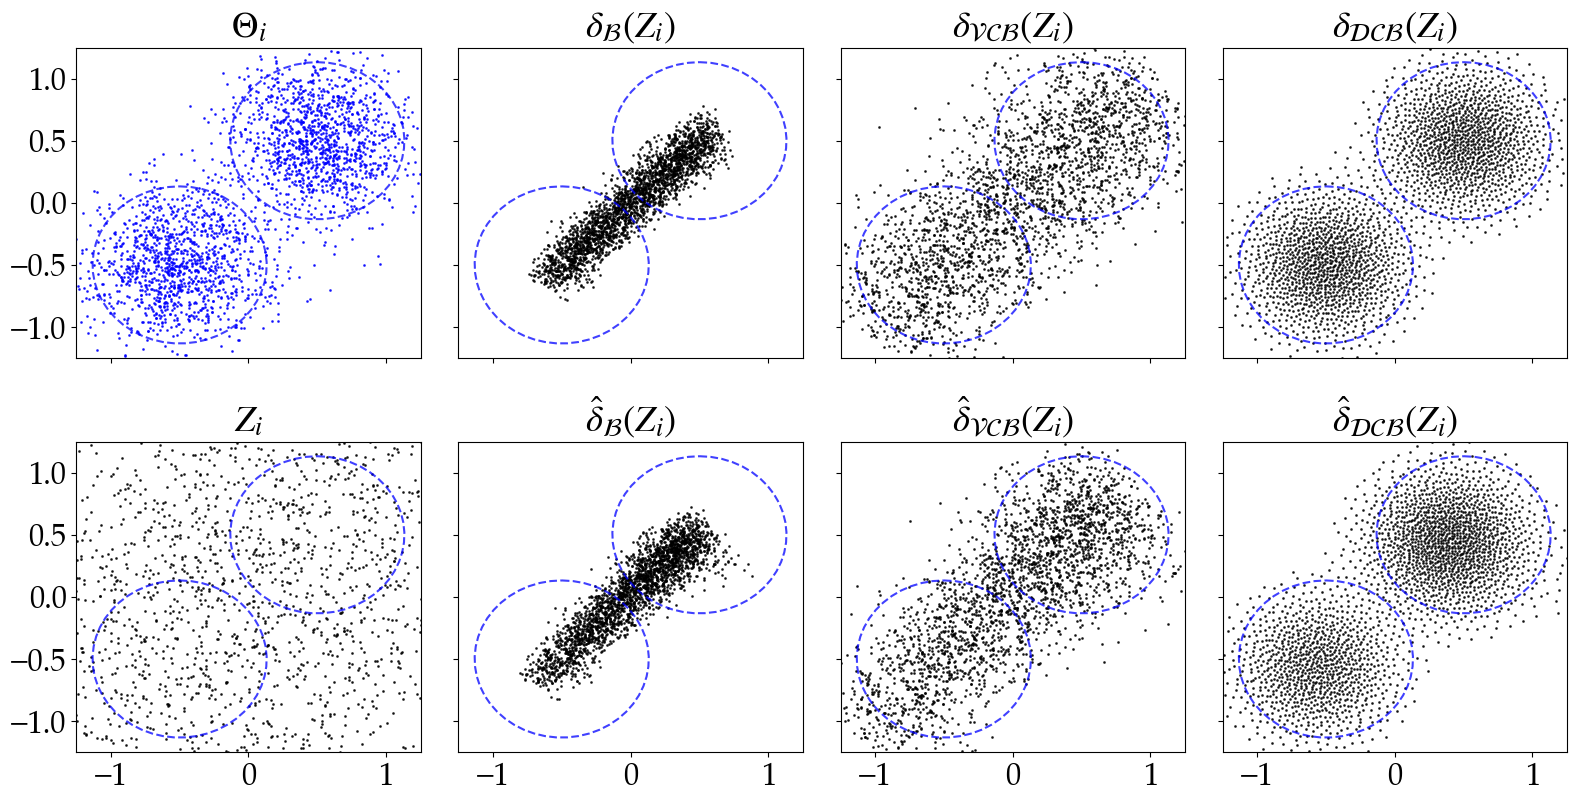

In [15]:
fig, ax = plt.subplots(2, 4, sharex=True, sharey=True, figsize=(16,8.5))

# top row
ax[0,0].set_title('$\\Theta_i$')
ax[0,0].scatter(Theta[:,0], Theta[:,1], s=Z_s,color='blue', alpha=Z_alpha)

    
ax[0,1].set_title('$\\delta_{\\mathcal{B}}(Z_i)$')
ax[0,1].scatter(ob[:,0], ob[:,1], s=Z_s,color='black', alpha=Z_alpha)

ax[0,2].set_title('$\\delta_{\\mathcal{VCB}}(Z_i)$')
ax[0,2].scatter(ovcb[:,0], ovcb[:,1], s=Z_s,color='black', alpha=Z_alpha)

ax[0,3].set_title('$\\delta_{\\mathcal{DCB}}(Z_i)$')
ax[0,3].scatter(odcb[:,0], odcb[:,1], s=Z_s,color='black', alpha=Z_alpha)

# bottom row

ax[1,0].set_title('$Z_i$')
ax[1,0].scatter(Z[:,0], Z[:,1], s=Z_s,color='black', alpha=Z_alpha)

ax[1,1].set_title('$\\hat{\\delta}_{\\mathcal{B}}(Z_i)$')
ax[1,1].scatter(eb[:,0], eb[:,1], s=Z_s,color='black', alpha=Z_alpha)

ax[1,2].set_title('$\\hat{\\delta}_{\\mathcal{VCB}}(Z_i)$')
ax[1,2].scatter(evcb[:,0], evcb[:,1], s=Z_s,color='black', alpha=Z_alpha)

ax[1,3].set_title('$\\hat{\\delta}_{\\mathcal{DCB}}(Z_i)$')
ax[1,3].scatter(edcb[:,0], edcb[:,1], s=Z_s,color='black', alpha=Z_alpha)

u = np.linspace(0,2*np.pi)
circ1 = center1 + 2*np.sqrt(tau2)*np.vstack([np.sin(u),np.cos(u)]).T
circ2 = center2 + 2*np.sqrt(tau2)*np.vstack([np.sin(u),np.cos(u)]).T
for i in range(2):
    for j in range(4):
        # if i > 0 or j > 0:
        ax[i,j].plot(circ1[:,0],circ1[:,1],color='blue',linestyle='dashed', alpha=0.75)
        ax[i,j].plot(circ2[:,0],circ2[:,1],color='blue',linestyle='dashed', alpha=0.75)
            # ax[i,j].scatter(Theta[:,0], Theta[:,1], s=Z_s,color='blue', alpha=G_alpha)

plt.xlim([-1.25,1.25])
plt.ylim([-1.25, 1.25])
plt.tight_layout()
plt.savefig('figs/sim_2d.pdf')
plt.savefig('figs/sim_2d.png')